# Panel 3 — Serie temporal y pronóstico de PM2.5
**Dos Limas, un mismo cielo · Rol C (Series temporales e infraestructura)**

> Este notebook **no reimplementa** la lógica de series: toda vive en `src/forecast.py`
> (fuente única, igual que Rol B con `models.py`). Aquí solo se narra el flujo CRISP-DM
> —*Modeling* y *Evaluation*— para la parte de pronóstico, llamando a ese módulo.
>
> La limpieza y la semilla oficial (`SEED = 96`) vienen de Rol A (`preprocessing.py`).

## 0. Setup

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

import forecast as F
from preprocessing import cargar_y_limpiar, SEED

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print(f"SEED={SEED} · objetivo={F.OBJETIVO} · freq={F.FREQ_DEFAULT} "
      f"· estacionalidad m={F.estacionalidad(F.FREQ_DEFAULT)} "
      f"· horizonte={F.HORIZONTE} · ventana test={F.PERIODOS_TEST}")

SEED=96 · objetivo=pm_25 · freq=MS · estacionalidad m=12 · horizonte=6 · ventana test=12


## 1. Datos

Se parte del dataset limpio de Rol A (0 % NaN en contaminantes). Para el pronóstico se
agrega el PM2.5 horario a **serie mensual** —la frecuencia donde la estacionalidad anual
(el "invierno limeño") es tratable con modelos clásicos (período $m = 12$)—.

In [2]:
df = cargar_y_limpiar(str(F.RUTA_DATOS))
print(f"{len(df):,} filas × {df.shape[1]} columnas · {df['estacion'].nunique()} estaciones")
df[["estacion", "fecha_hora", "pm_25", "pm_25_imputado"]].head()

514,680 filas × 18 columnas · 10 estaciones


,estacion,fecha_hora,pm_25,pm_25_imputado
0,ATE,2014-10-01 00:00:00,43.200,False
1,ATE,2014-10-01 01:00:00,45.500,False
2,ATE,2014-10-01 02:00:00,54.500,False
3,ATE,2014-10-01 03:00:00,66.800,False
4,ATE,2014-10-01 04:00:00,76.800,False


### 1.1 Las "Dos Limas" en la serie

Comparamos una estación de **alta** contaminación (ATE) con una de **baja**
(CAMPO DE MARTE) y el promedio de Lima. El recorte de cola con PM2.5 mayormente imputado
(ver `CONTEXTO_ROL_A` §4) evita pronosticar sobre climatología.

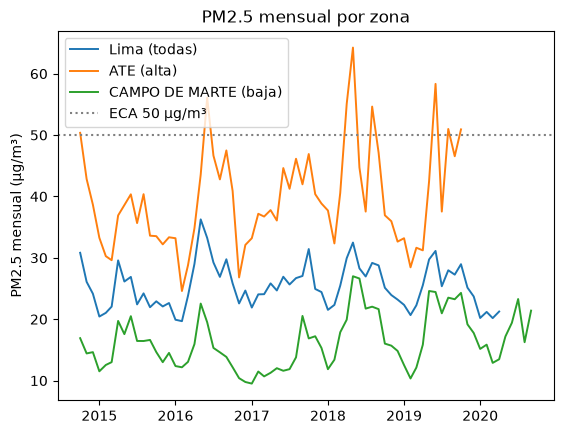

In [3]:
serie_lima = F.construir_serie(df, estacion=None)
serie_ate  = F.construir_serie(df, estacion="ATE")
serie_cdm  = F.construir_serie(df, estacion="CAMPO DE MARTE")

fig, ax = plt.subplots()
for s, lbl in [(serie_lima, "Lima (todas)"), (serie_ate, "ATE (alta)"),
               (serie_cdm, "CAMPO DE MARTE (baja)")]:
    ax.plot(s.index, s.values, lw=1.4, label=lbl)
ax.axhline(50, ls=":", color="gray", label="ECA 50 µg/m³")
ax.set_ylabel("PM2.5 mensual (µg/m³)"); ax.legend(); ax.set_title("PM2.5 mensual por zona")
plt.show()

El pico anual recurrente (mayo–octubre) es la estacionalidad que los modelos deben
capturar; ATE se mantiene sistemáticamente por encima de CAMPO DE MARTE — dos regímenes
distintos bajo el mismo cielo.

## 2. Split cronológico

Hold-out **sin barajar**: los últimos `PERIODOS_TEST` meses se reservan para medir el
error; el modelo elegido se reajusta luego sobre toda la serie para el pronóstico futuro.

In [4]:
train, test = F.dividir_serie(serie_lima)
print(f"train: {len(train)} meses ({train.index.min().date()}→{train.index.max().date()})")
print(f"test : {len(test)} meses ({test.index.min().date()}→{test.index.max().date()})")

train: 55 meses (2014-10-01→2019-04-01)
test : 12 meses (2019-05-01→2020-04-01)


## 3. Modelos y evaluación (MAPE, RMSE)

Tres candidatos, de menos a más sofisticado:

1. **Naive estacional** — copia el último ciclo anual. Piso honesto: un modelo solo se
   justifica si le gana.
2. **Holt-Winters** — suavizado exponencial con tendencia y estacionalidad aditivas.
3. **SARIMA** $(1,1,1)(1,0,1)_{12}$ — modelo estacional con intervalo de confianza.

In [5]:
tabla, resultados, mejor, (tr, te) = F.comparar_modelos(serie_lima)
tabla.rename(columns={"mape": "MAPE %", "rmse": "RMSE", "mae": "MAE"})

,MAPE %,RMSE,MAE
naive_estacional,8.180,2.342,2.039
sarima,11.298,3.262,2.910
holt_winters,11.855,3.296,3.030


In [6]:
print(f"Mejor modelo (menor MAPE): {mejor}")

Mejor modelo (menor MAPE): naive_estacional


### 3.1 Ajuste sobre el tramo de test

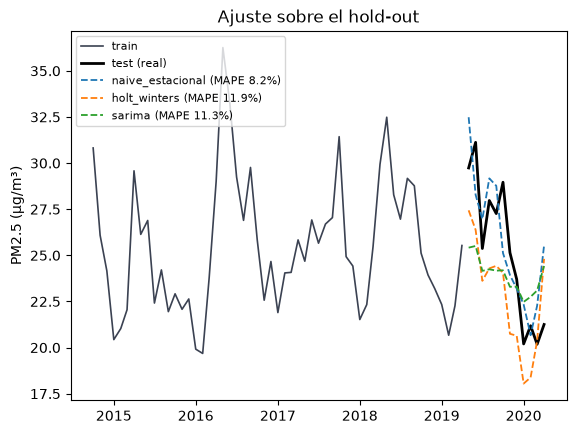

In [7]:
fig, ax = plt.subplots()
ax.plot(train.index, train.values, color="#3b4252", lw=1.2, label="train")
ax.plot(test.index, test.values, color="black", lw=2, label="test (real)")
for nombre, r in resultados.items():
    ax.plot(r["yhat"].index, r["yhat"].values, "--", lw=1.3,
            label=f'{nombre} (MAPE {r["mape"]:.1f}%)')
ax.set_ylabel("PM2.5 (µg/m³)"); ax.legend(fontsize=8); ax.set_title("Ajuste sobre el hold-out")
plt.show()

## 4. Pronóstico final (≥ 4 períodos)

El modelo ganador se reajusta sobre la **serie completa** y proyecta `HORIZONTE` meses.

In [8]:
paq = F.serie_y_pronostico(df, estacion=None)   # serie → comparar → mejor → futuro
F.graficar(paq)
plt.show()
paq["futuro"].round(2)

,yhat
2020-05-01,29.740
2020-06-01,31.120
2020-07-01,25.370
2020-08-01,27.970
2020-09-01,27.260
2020-10-01,28.960


## 5. Cifras auditables

`forecast.py` persiste las métricas en `models/forecast_metrics.json` — **fuente única**
para el Panel 3 y el Reporte PDF (Rol D). No copiar números a mano.

In [9]:
import json
from pathlib import Path
ruta = F.RUTA_METRICS
if not ruta.exists():
    F.guardar_metrics_json(paq)          # genera si aún no existe
doc = json.loads(Path(ruta).read_text(encoding="utf-8"))
print(f"mejor_modelo: {doc['mejor_modelo']} · n_train={doc['n_train']} · n_test={doc['n_test']}")
pd.DataFrame(doc["modelos"]).T

mejor_modelo: naive_estacional · n_train=55 · n_test=12


,mape,rmse,mae
naive_estacional,8.180,2.342,2.039
sarima,11.298,3.262,2.910
holt_winters,11.855,3.296,3.030


## 6. Conclusiones para la presentación

- El pronóstico usa **solo el pasado de la propia serie** (sin fuga): es un problema de
  extrapolación temporal, distinto de la clasificación de Rol B.
- Reportamos **MAPE y RMSE** sobre un hold-out cronológico y elegimos por MAPE; el
  *naive estacional* actúa de baseline defendible.
- El período estacional $m=12$ captura el invierno limeño; a frecuencia diaria/semanal
  el módulo ajusta $m$ automáticamente (7 / 52).
- Parámetros tuneables en vivo desde el Panel 3: estación, frecuencia, horizonte y
  ventana de test.